# 03 — Black–Scholes: Vega por Pathwise vs. Diferencias Finitas

**Objetivo del notebook.** Comparar dos estimadores Monte Carlo de la Vega de una opción europea bajo Black–Scholes:

1. **Pathwise (PW):** estimador insesgado obtenido derivando $S_T$ respecto a $\sigma$ bajo la esperanza.
2. **Diferencias Finitas centradas (FD)** con Common Random Numbers (CRN).

El estimador para $pathwise$ es:

$$\mathcal{V}^{PW} = e^{-rT}\, \mathbb{E}\!\left[\mathbf{1}_{S_T > K}\, S_T (W_T - \sigma T)\right], \qquad \mathcal{V}^{FD} = \frac{V(\sigma+h) - V(\sigma-h)}{2h}.$$

> **Nota.** Existe una versión equivalente que evita reconstruir $W_T$:
> $$\frac{\partial S_T}{\partial \sigma} = \frac{S_T}{\sigma}\bigl[\log(S_T/S_0) - (r + \tfrac{1}{2}\sigma^2)T\bigr].$$
> Numéricamente ambas son equivalentes; en `bs_utils.py` se utiliza la primera por simetría con la derivación clásica.

In [6]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bs_utils import (BS_vega,GeneratePathsGBM_givenZ,PathwiseVega,FD_Vega)

np.set_printoptions(suppress=True, precision=6)

## 1. Parámetros del experimento

In [7]:
CP        = 'call'
S0        = 100.0
K         = 100.0
sigma     = 0.20
r         = 0.05
T         = 1.0
t         = 0.0
NoOfSteps = 1

SEED      = 3

## 2. Validación puntual

In [8]:
N = 100_000
h = 0.01 * sigma     # paso relativo del 1 % sobre sigma

rng = np.random.default_rng(SEED)
Z = rng.normal(0.0, 1.0, (N, NoOfSteps))

paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)

vega_BS = BS_vega(S0, K, sigma, t, T, r)
vega_PW = PathwiseVega(CP, S0, paths["S"], K, r, T, sigma)
vega_FD = FD_Vega(CP, S0, K, sigma, T, r, h, Z)

print(f"Vega BS (analítica): {vega_BS:.6f}")
print(f"Vega PW (pathwise):  {vega_PW:.6f}    error abs = {abs(vega_PW - vega_BS):.2e}")
print(f"Vega FD (centrada):  {vega_FD:.6f}    error abs = {abs(vega_FD - vega_BS):.2e}")

Vega BS (analítica): 37.524035
Vega PW (pathwise):  37.573702    error abs = 4.97e-02
Vega FD (centrada):  37.574375    error abs = 5.03e-02


**Lectura.** Ambos estimadores son consistentes con la Vega analítica. La presencia del factor $W_T - \sigma T$ en el estimador pathwise introduce una varianza ligeramente mayor que la observada en Delta, donde el integrando se reduce al cociente $S_T / S_0$ por el indicador.

## 3. Convergencia frente a $N$

In [23]:
N_list = [1000, 5000, 10000, 50000, 100000]
results = []

rng = np.random.default_rng(SEED)

for N in N_list:
    Z = rng.normal(0.0, 1.0, (N, NoOfSteps))
    paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)
    
    vega_PW = PathwiseVega(CP, S0, paths["S"], K, r, T, sigma)
    vega_FD = FD_Vega(CP, S0, K, sigma, T, r, h, Z)
    
    results.append([
        N,
        vega_PW, abs(vega_PW - vega_BS),
        vega_FD, abs(vega_FD - vega_BS),
        1.0/np.sqrt(N)
    ])

df_N = pd.DataFrame(results, columns=[
    "N", "Vega_PW", "Error_PW", "Vega_FD", "Error_FD", "MC_rate"
])
df_N

,N,Vega_PW,Error_PW,Vega_FD,Error_FD,MC_rate
0,1000,36.853023,0.671012,36.876130,0.647904,0.031623
1,5000,37.591953,0.067918,37.589640,0.065606,0.014142
2,10000,38.018142,0.494108,38.011863,0.487828,0.010000
3,50000,37.436846,0.087188,37.437453,0.086581,0.004472
4,100000,37.565933,0.041898,37.560796,0.036762,0.003162


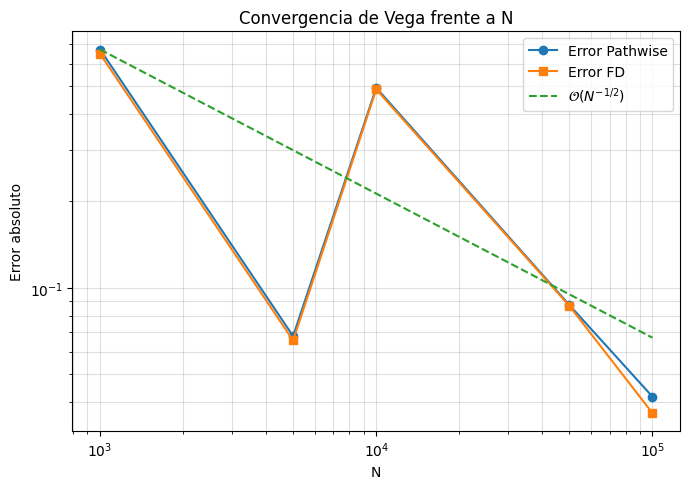

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(df_N["N"], df_N["Error_PW"], "o-", label="Error Pathwise")
ax.loglog(df_N["N"], df_N["Error_FD"], "s-", label="Error FD")
# Reescalado de la curva 1/sqrt(N) al primer punto
scale = df_N["Error_PW"].iloc[0] * np.sqrt(df_N["N"].iloc[0])
ax.loglog(df_N["N"], scale/np.sqrt(df_N["N"]), "--",
          label=r"$\mathcal{O}(N^{-1/2})$")
ax.set_xlabel("N")
ax.set_ylabel("Error absoluto")
ax.set_title("Convergencia de Vega frente a N")
ax.grid(True, which="both", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

**Lectura.** La precisión es similar entre métodos. Ambos estimadores muestran una reducción global del error al aumentar $N$, compatible con la tasa
$\mathcal{O}(N^{-1/2})$ característica de Monte Carlo, aunque con oscilaciones apreciables debidas al ruido estadístico.

En el caso de la Vega, la variabilidad es más pronunciada que para la Delta, lo que se traduce en trayectorias menos suaves. Este comportamiento indica que, en este régimen, el error está dominado por la varianza del método Monte Carlo, más que por las diferencias estructurales entre estimadores.

## 4. Estabilidad estadística: varianza del estimador

Replicaciones independientes con $M$ semillas para comparar dispersión empírica.

In [25]:
def estimadores_vega(CP, S0, K, r, T, sigma, NoOfPaths, NoOfSteps, h, rng):
    """    Devuelve (vega_PW, vega_FD) usando CRN. """
    Z = rng.normal(0.0, 1.0, (NoOfPaths, NoOfSteps))
    
    paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)
    vega_PW = PathwiseVega(CP, S0, paths["S"], K, r, T, sigma)
    vega_FD = FD_Vega(CP, S0, K, sigma, T, r, h, Z)
    
    return vega_PW, vega_FD

In [26]:
N_list = [1000, 5000, 10000, 50000]
M = 100

rng = np.random.default_rng(SEED)
results_var = []

for N in N_list:
    pw_vals = np.empty(M)
    fd_vals = np.empty(M)
    
    for j in range(M):
        vega_PW, vega_FD = estimadores_vega(
            CP, S0, K, r, T, sigma, N, NoOfSteps, h, rng
        )
        pw_vals[j] = vega_PW
        fd_vals[j] = vega_FD
    
    results_var.append([
        N,
        np.mean(pw_vals), np.var(pw_vals, ddof=1), np.std(pw_vals, ddof=1),
        np.mean(fd_vals), np.var(fd_vals, ddof=1), np.std(fd_vals, ddof=1),
    ])

df_var = pd.DataFrame(results_var, columns=[
    "N",
    "Mean_PW", "Var_PW", "Std_PW",
    "Mean_FD", "Var_FD", "Std_FD"
])
df_var

,N,Mean_PW,Var_PW,Std_PW,Mean_FD,Var_FD,Std_FD
0,1000,37.596570,0.319977,0.565666,37.595364,0.315056,0.561298
1,5000,37.528261,0.068775,0.262251,37.528012,0.068780,0.262259
2,10000,37.503818,0.035746,0.189067,37.503697,0.035459,0.188306
3,50000,37.525569,0.006540,0.080868,37.525570,0.006472,0.080447


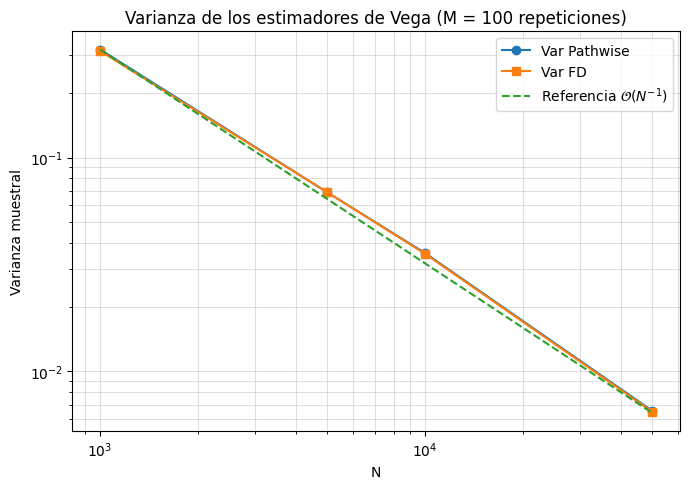

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(df_var["N"], df_var["Var_PW"], "o-", label="Var Pathwise")
ax.loglog(df_var["N"], df_var["Var_FD"], "s-", label="Var FD")

scale = df_var["Var_PW"].iloc[0] * df_var["N"].iloc[0]
ax.loglog(df_var["N"], scale / df_var["N"], "--",
          label=r"Referencia $\mathcal{O}(N^{-1})$")

ax.set_xlabel("N")
ax.set_ylabel("Varianza muestral")
ax.set_title(f"Varianza de los estimadores de Vega (M = {M} repeticiones)")
ax.grid(True, which="both", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

**Lectura.** La varianza decrece a tasa $1/N$ para ambos estimadores. La presencia del término $W_T$ en el integrando de PW hace que su varianza sea ligeramente superior a la del Delta, pero permanece comparable a la de FD bajo CRN.

## 5. Sensibilidad respecto al paso $h$

Como en el caso de Delta, el estimador pathwise no depende de $h$. El estimador FD presenta el compromiso sesgo–varianza habitual.

In [32]:
h_list = [0.1, 0.05, 0.01, 0.005, 0.001]
N_h = 10_000
M_h = 200

rng = np.random.default_rng(SEED)

pw_all = np.empty(M_h)
fd_all = {h_val: np.empty(M_h) for h_val in h_list}

for j in range(M_h):
    Z = rng.normal(0.0, 1.0, (N_h, NoOfSteps))
    
    paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)
    pw_all[j] = PathwiseVega(CP, S0, paths["S"], K, r, T, sigma)
    
    for h_val in h_list:
        fd_all[h_val][j] = FD_Vega(CP, S0, K, sigma, T, r, h_val, Z)

mean_pw = np.mean(pw_all);   var_pw = np.var(pw_all, ddof=1)
bias_pw = mean_pw - vega_BS; mse_pw = var_pw + bias_pw**2

rows = []
for h_val in h_list:
    fd_v = fd_all[h_val]
    mean_fd = np.mean(fd_v); var_fd = np.var(fd_v, ddof=1)
    bias_fd = mean_fd - vega_BS; mse_fd = var_fd + bias_fd**2
    rows.append([
        h_val,
        mean_pw, bias_pw, abs(bias_pw), var_pw, mse_pw,
        mean_fd, bias_fd, abs(bias_fd), var_fd, mse_fd
    ])

df_h = pd.DataFrame(rows, columns=[
    "h",
    "Mean_PW", "Bias_PW", "AbsBias_PW", "Var_PW", "MSE_PW",
    "Mean_FD", "Bias_FD", "AbsBias_FD", "Var_FD", "MSE_FD"
])
df_h

,h,Mean_PW,Bias_PW,AbsBias_PW,Var_PW,MSE_PW,Mean_FD,Bias_FD,AbsBias_FD,Var_FD,MSE_FD
0,0.100,37.518255,-0.005779,0.005779,0.032361,0.032394,37.124928,-0.399107,0.399107,0.030218,0.189504
1,0.050,37.518255,-0.005779,0.005779,0.032361,0.032394,37.437840,-0.086195,0.086195,0.031157,0.038586
2,0.010,37.518255,-0.005779,0.005779,0.032361,0.032394,37.514789,-0.009245,0.009245,0.031813,0.031899
3,0.005,37.518255,-0.005779,0.005779,0.032361,0.032394,37.517070,-0.006965,0.006965,0.031956,0.032004
4,0.001,37.518255,-0.005779,0.005779,0.032361,0.032394,37.518094,-0.005940,0.005940,0.032193,0.032229


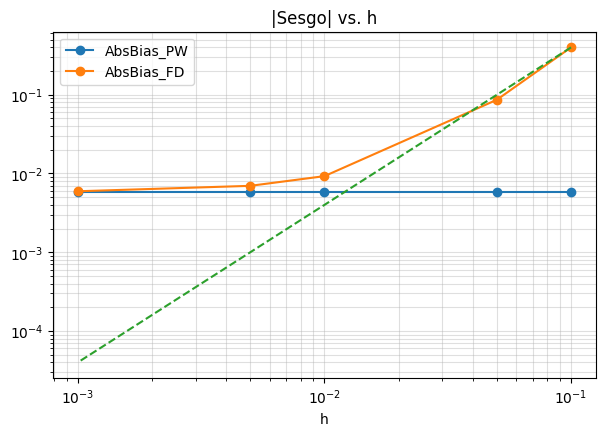

In [40]:
df_h.plot(x="h", y=["AbsBias_PW", "AbsBias_FD"], logx=True, logy=True,
          marker="o", figsize=(7,4.5), title="|Sesgo| vs. h").grid(True, which="both", alpha=0.4)

scale = df_h["AbsBias_FD"].iloc[0] / (df_h["h"].iloc[0]**2)
plt.loglog(df_h["h"], scale * df_h["h"]**2, "--",label=r"Referencia $\mathcal{O}(h^2)$")

plt.show()

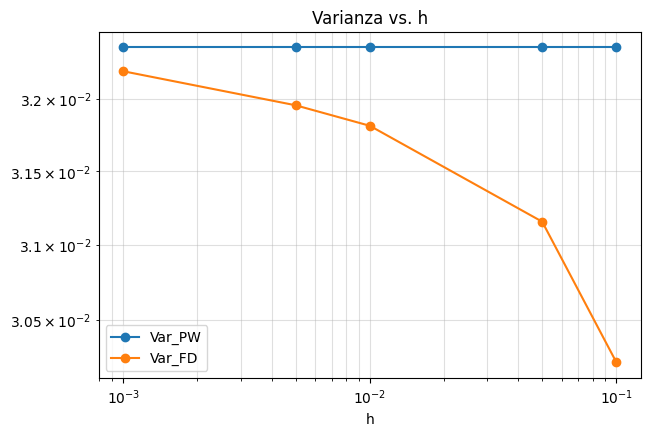

In [41]:
df_h.plot(x="h", y=["Var_PW", "Var_FD"], logx=True, logy=True,
          marker="o", figsize=(7,4.5), title="Varianza vs. h").grid(True, which="both", alpha=0.4)
plt.show()

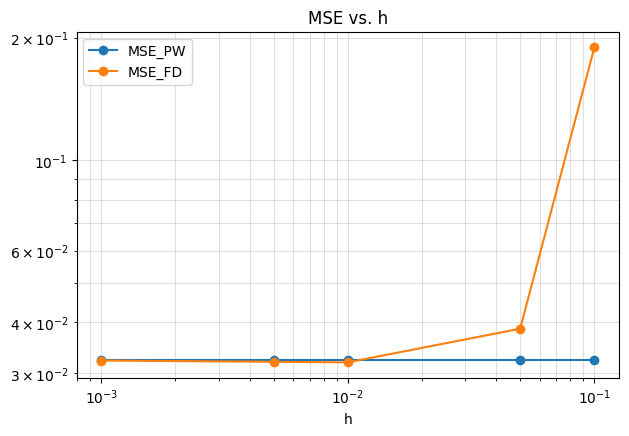

In [42]:
df_h.plot(x="h", y=["MSE_PW", "MSE_FD"], logx=True, logy=True,
          marker="o", figsize=(7,4.5), title="MSE vs. h").grid(True, which="both", alpha=0.4)
plt.show()

**Lectura.**
- Pathwise: estadísticas constantes en $h$ (líneas horizontales).
- FD: el sesgo decrece como $h^2$ para $h$ moderado; para $h$ muy pequeño aparecen errores de muestreo y de redondeo, inflando el MSE.
- En el caso ATM y $T = 1$ año, el $h$ óptimo de FD se sitúa en torno a $h \approx 0{,}01$–$0{,}05$ veces $\sigma$.

## 6. Conclusiones del notebook

1. PW y FD producen estimadores consistentes de la Vega analítica, con tasa de convergencia $\mathcal{O}(N^{-1/2})$.
2. La **independencia respecto a $h$** del estimador pathwise es su ventaja operativa principal.
3. La precisión de ambos métodos es similar para una call europea bajo BS, debido a la suavidad del payoff y al uso sistemático de CRN en FD.